In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [2]:
# 1. Load dataset
data = load_breast_cancer()
X = data.data
y = data.target  # 0 = malignant, 1 = benign

# Convert to healthcare decision problem:
# malignant (0) → needs treatment (1)
# benign (1) → no treatment (0)
y = np.where(y == 0, 1, 0)

# 2. Train observation model (belief estimator)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
# Create pipeline
obs_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

obs_model.fit(X_train, y_train)
obs_model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [4]:
# 3. Reward function
def get_reward(action, true_state):
    if action == 1 and true_state == 1:   # correct treatment
        return 10
    elif action == 0 and true_state == 0: # correct no treatment
        return 5
    elif action == 1 and true_state == 0: # unnecessary treatment
        return -5
    else:                                # missed treatment
        return -10

In [5]:
# 4. Policy based on belief
def choose_action(belief, epsilon=0.2):
    if random.random() < epsilon:
        return random.choice([0, 1])
    return 1 if belief > 0.5 else 0

In [6]:
# 5. Simulation (episodes)
episodes = 200
rewards = []

epsilon = 1.0

for ep in range(episodes):
    total_reward = 0
    
    for i in range(len(X_test)):
        belief = obs_model.predict_proba(X_test[i].reshape(1, -1))[0][1]
        
        if random.random() < epsilon:
            action = random.choice([0, 1])
        else:
            action = 1 if belief > 0.5 else 0
        
        reward = get_reward(action, y_test[i])
        total_reward += reward
    
    rewards.append(total_reward)
    
    epsilon *= 0.98  # decay

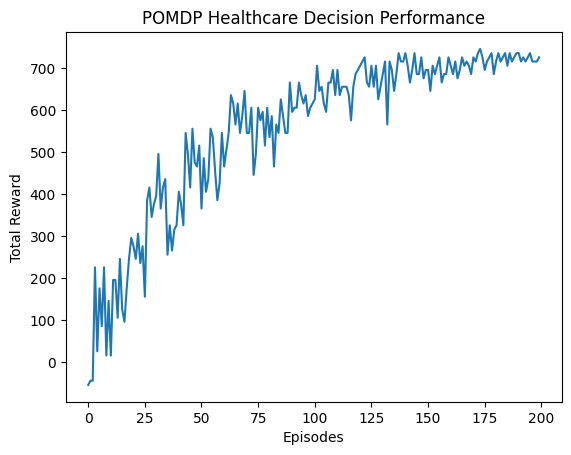

In [7]:
# 6. Plot learning / performance
plt.figure()
plt.plot(rewards)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("POMDP Healthcare Decision Performance")
plt.show()

In [8]:
# 7. Example decisions
print("\nSample Decisions:")
for i in range(5):
    obs = X_test[i].reshape(1, -1)
    belief = obs_model.predict_proba(obs)[0][1]
    action = choose_action(belief)
    
    print(f"Belief: {belief:.2f}, Action: {'Treat' if action==1 else 'No Treat'}, True: {y_test[i]}")


Sample Decisions:
Belief: 0.11, Action: No Treat, True: 0
Belief: 1.00, Action: Treat, True: 1
Belief: 1.00, Action: No Treat, True: 1
Belief: 0.00, Action: No Treat, True: 0
Belief: 0.00, Action: No Treat, True: 0
